# B.1 — ASRA: Nash Bargaining Scheduler for AI Subagents

## Game Theory Final Project Notebook

This notebook implements **Adaptive Strategic Reasoning Architecture (ASRA)** as a cooperative bargaining model.

The main idea is to model reasoning subagents as players in a cooperative game. These subagents bargain over a finite reasoning budget, and the scheduler chooses a resource allocation that balances efficiency and fairness.

This version upgrades the earlier Nash-inspired heuristic into a **real Nash bargaining optimization problem**. Instead of allocating budget only in proportion to surplus, ASRA now solves:

```txt
max_x Σ log(u_i(x_i) - d_i)
```

subject to:

```txt
Σx_i = B
x_i ≥ 0
u_i(x_i) > d_i
```

This makes the implementation much closer to the paper **Multi-Task Learning as a Bargaining Game**, where tasks bargain over a shared model update direction. In ASRA, reasoning subagents bargain over limited reasoning resources.

## Core Question

Can a Nash bargaining scheduler produce a better balance between total utility and fairness than equal allocation, greedy allocation, or a simple heuristic scheduler?


# B.1 — Lock the Mathematical Foundation

## Formal Cooperative Game Theory Model

| Game Theory Concept | ASRA Version |
|---|---|
| Players | Reasoning subagents: Planner, Researcher, Critic, Verifier |
| Resource | Finite reasoning budget `B` |
| Agreement / Strategy | Allocation vector `x = (x_1, ..., x_N)` |
| Feasible Set | `Σx_i = B`, `x_i ≥ 0` |
| Utility | Budget-dependent usefulness of agent `i` |
| Disagreement Point | Baseline utility if bargaining fails |
| Solution Concept | Nash bargaining solution |

## Players

```txt
Subagents = Planner, Researcher, Critic, Verifier
```

## Resource

```txt
Finite reasoning budget B
```

## Allocation Variables

```txt
x_i = share of budget allocated to agent i
Σx_i = B
x_i ≥ 0
```

## Utility Function

The previous version used a static utility score:

```txt
u_i = relevance_i + urgency_i + historical_success_i - cost_i
```

This version uses a stronger budget-dependent utility:

```txt
u_i(x_i) = base_i + x_i(value_i) - cost_i(x_i)^2
```

where:

```txt
value_i = relevance_i + urgency_i + historical_success_i
```

This matters because the allocation `x_i` now directly affects the utility each agent receives. The quadratic cost term creates diminishing returns, so the model does not simply give all resources to one agent.

## Disagreement Point

```txt
d_i = minimum baseline utility if bargaining fails
```

In this implementation, the disagreement point is set to each agent's baseline utility:

```txt
d_i = base_i
```

## Nash Bargaining Objective

```txt
max_x Σ log(u_i(x_i) - d_i)
```

## Subject to

```txt
Σx_i = B
x_i ≥ 0
u_i(x_i) > d_i
```

The log objective rewards allocations where all agents receive positive surplus above disagreement. This creates proportional fairness: improving one agent while severely harming another becomes costly.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


## 1. Define the Subagents

Each agent has a historical success value and a cost. These are fixed starting properties.

The task-specific values, like relevance and urgency, will change depending on the task.

In [2]:
agents = {
    "Planner": {
        "past_success": 0.80,
        "cost": 0.25,
        "base": 0.10,
        "description": "Breaks the task into steps and creates a strategy."
    },
    "Researcher": {
        "past_success": 0.70,
        "cost": 0.35,
        "base": 0.10,
        "description": "Gathers facts, context, and supporting information."
    },
    "Critic": {
        "past_success": 0.75,
        "cost": 0.30,
        "base": 0.10,
        "description": "Finds weaknesses, risks, and missing assumptions."
    },
    "Verifier": {
        "past_success": 0.78,
        "cost": 0.28,
        "base": 0.10,
        "description": "Checks accuracy, consistency, and correctness."
    }
}

pd.DataFrame(agents).T


,past_success,cost,base,description
Planner,0.8,0.25,0.1,Breaks the task into steps and creates a strat...
Researcher,0.7,0.35,0.1,"Gathers facts, context, and supporting informa..."
Critic,0.75,0.3,0.1,"Finds weaknesses, risks, and missing assumptions."
Verifier,0.78,0.28,0.1,"Checks accuracy, consistency, and correctness."


## 2. Define Example Tasks

Each task gives each agent a different relevance and urgency score.

For example, a research-heavy task should give the Researcher a high relevance score. A math-checking task should give the Verifier a high relevance score.

In [3]:
tasks = {
    "Easy Writing Task": {
        "Planner": {"relevance": 0.60, "urgency": 0.50},
        "Researcher": {"relevance": 0.20, "urgency": 0.20},
        "Critic": {"relevance": 0.50, "urgency": 0.40},
        "Verifier": {"relevance": 0.40, "urgency": 0.30},
    },
    "Research-Heavy Task": {
        "Planner": {"relevance": 0.70, "urgency": 0.60},
        "Researcher": {"relevance": 0.95, "urgency": 0.90},
        "Critic": {"relevance": 0.65, "urgency": 0.50},
        "Verifier": {"relevance": 0.75, "urgency": 0.70},
    },
    "Math Verification Task": {
        "Planner": {"relevance": 0.50, "urgency": 0.40},
        "Researcher": {"relevance": 0.25, "urgency": 0.20},
        "Critic": {"relevance": 0.70, "urgency": 0.65},
        "Verifier": {"relevance": 0.95, "urgency": 0.95},
    },
    "Planning Task": {
        "Planner": {"relevance": 0.95, "urgency": 0.90},
        "Researcher": {"relevance": 0.55, "urgency": 0.40},
        "Critic": {"relevance": 0.65, "urgency": 0.50},
        "Verifier": {"relevance": 0.45, "urgency": 0.35},
    },
    "Ambiguous Strategic Task": {
        "Planner": {"relevance": 0.85, "urgency": 0.80},
        "Researcher": {"relevance": 0.75, "urgency": 0.65},
        "Critic": {"relevance": 0.90, "urgency": 0.85},
        "Verifier": {"relevance": 0.70, "urgency": 0.65},
    },
}

## 3. Utility Function

This version separates **agent value** from **realized utility**.

First, each agent receives a task-specific value score:

```txt
value_i = relevance_i + urgency_i + historical_success_i
```

Then the actual utility depends on how much reasoning budget the agent receives:

```txt
u_i(x_i) = base_i + x_i(value_i) - cost_i(x_i)^2
```

This is stronger than the earlier static formula because budget allocation now matters directly. The quadratic cost term represents diminishing returns: after a point, giving more budget to the same agent becomes less efficient.


In [4]:
def compute_agent_values(task_name):
    """Compute task-specific parameters for all agents."""
    task = tasks[task_name]
    rows = []

    for agent_name, base_info in agents.items():
        relevance = task[agent_name]["relevance"]
        urgency = task[agent_name]["urgency"]
        past_success = base_info["past_success"]
        cost = base_info["cost"]
        base = base_info["base"]
        value = relevance + urgency + past_success
        static_score = relevance + urgency + past_success - cost

        rows.append({
            "agent": agent_name,
            "relevance": relevance,
            "urgency": urgency,
            "past_success": past_success,
            "cost": cost,
            "base": base,
            "value": value,
            "static_score": static_score
        })

    return pd.DataFrame(rows)

compute_agent_values("Research-Heavy Task")


,agent,relevance,urgency,past_success,cost,base,value,static_score
0,Planner,0.70,0.6,0.80,0.25,0.1,2.10,1.85
1,Researcher,0.95,0.9,0.70,0.35,0.1,2.55,2.20
2,Critic,0.65,0.5,0.75,0.30,0.1,1.90,1.60
3,Verifier,0.75,0.7,0.78,0.28,0.1,2.23,1.95


## 4. Allocation Methods

We compare four schedulers.

### Equal Allocation
Every agent gets the same budget.

### Greedy Allocation
Agents with higher value receive a more concentrated allocation.

### Heuristic Scheduler
The older MVP scheduler allocates based on the static score:

```txt
score = relevance + urgency + past_success - cost
```

### Nash Bargaining Scheduler
This version solves the formal Nash bargaining problem:

```txt
max_x Σ log(u_i(x_i) - d_i)
```

subject to:

```txt
Σx_i = B
x_i ≥ 0
u_i(x_i) > d_i
```

This is the most important upgrade in Iteration B.


In [5]:
def equal_allocation(values_df, total_budget=100):
    n = len(values_df)
    return np.ones(n) * (total_budget / n)


def greedy_allocation(values_df, total_budget=100, temperature=3.0):
    """
    Greedy allocation using a softmax-style weighting.
    Higher temperature makes allocation more concentrated on high-value agents.
    """
    values = values_df["value"].to_numpy()
    exp_values = np.exp(temperature * values)
    weights = exp_values / exp_values.sum()
    return weights * total_budget


def heuristic_allocation(values_df, total_budget=100, epsilon=1e-6):
    """
    Earlier MVP-style scheduler using the static score formula.
    This is kept as a baseline, not as the final game theory method.
    """
    scores = values_df["static_score"].to_numpy()
    scores = np.maximum(scores, epsilon)
    weights = scores / scores.sum()
    return weights * total_budget


def realized_utility(values_df, allocations, total_budget=100):
    """
    Compute u_i(x_i) = base_i + x_i * value_i - cost_i * x_i^2.
    x_i is normalized as the share of the total budget.
    """
    x = np.asarray(allocations, dtype=float) / total_budget
    base = values_df["base"].to_numpy(dtype=float)
    value = values_df["value"].to_numpy(dtype=float)
    cost = values_df["cost"].to_numpy(dtype=float)
    return base + value * x - cost * (x ** 2)


def nash_bargaining_allocation(values_df, total_budget=100, min_share=1e-6):
    """
    Formal Nash bargaining scheduler.

    Solves:
        max_x sum_i log(u_i(x_i) - d_i)

    subject to:
        sum_i x_i = total_budget
        x_i >= 0
        u_i(x_i) > d_i

    Here d_i = base_i, so surplus is the utility gained above baseline.
    """
    n = len(values_df)
    x0 = np.ones(n) * (total_budget / n)
    disagreement = values_df["base"].to_numpy(dtype=float)

    def objective(allocation):
        utilities = realized_utility(values_df, allocation, total_budget)
        surplus = utilities - disagreement
        if np.any(surplus <= 0):
            return 1e9
        return -np.sum(np.log(surplus))

    constraints = [{"type": "eq", "fun": lambda allocation: np.sum(allocation) - total_budget}]
    bounds = [(min_share, total_budget) for _ in range(n)]

    result = minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-12}
    )

    if not result.success:
        print("Warning: Nash optimization did not fully converge:", result.message)

    return result.x


## 5. Run One Example Task

This shows the allocation produced by each scheduler for one task.

The key column is **Nash Bargaining Allocation**, which comes from solving the actual Nash objective instead of the earlier proportional shortcut.


In [6]:
def run_allocations_for_task(task_name, total_budget=100):
    values_df = compute_agent_values(task_name)

    result = values_df[["agent", "value", "static_score"]].copy()
    result["Equal Allocation"] = equal_allocation(values_df, total_budget)
    result["Greedy Allocation"] = greedy_allocation(values_df, total_budget)
    result["Heuristic Allocation"] = heuristic_allocation(values_df, total_budget)
    result["Nash Bargaining Allocation"] = nash_bargaining_allocation(values_df, total_budget)

    for method in ["Equal Allocation", "Greedy Allocation", "Heuristic Allocation", "Nash Bargaining Allocation"]:
        result[method.replace("Allocation", "Utility")] = realized_utility(values_df, result[method].to_numpy(), total_budget)

    return result

example_result = run_allocations_for_task("Research-Heavy Task")
example_result


,agent,value,static_score,Equal Allocation,Greedy Allocation,Heuristic Allocation,Nash Bargaining Allocation,Equal Utility,Greedy Utility,Heuristic Utility,Nash Bargaining Utility
0,Planner,2.10,1.85,25.0,14.528089,24.342105,25.106240,0.609375,0.399813,0.596371,0.611473
1,Researcher,2.55,2.20,25.0,56.041020,28.947368,24.984476,0.715625,1.419125,0.808830,0.715256
2,Critic,1.90,1.60,25.0,7.973184,21.052632,24.846605,0.556250,0.249583,0.486704,0.553565
3,Verifier,2.23,1.95,25.0,21.457708,25.657895,25.062679,0.640000,0.565615,0.653738,0.641310


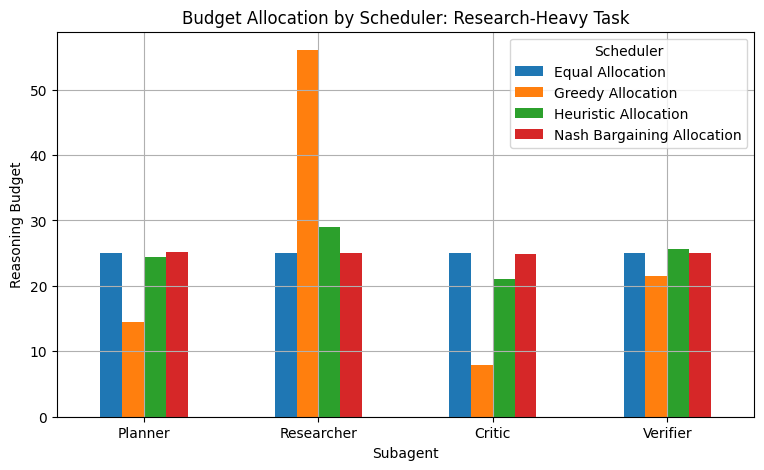

In [7]:
def plot_task_allocations(task_name):
    result = run_allocations_for_task(task_name)
    plot_df = result.set_index("agent")[[
        "Equal Allocation", 
        "Greedy Allocation", 
        "Heuristic Allocation", 
        "Nash Bargaining Allocation"
    ]]

    ax = plot_df.plot(kind="bar")
    ax.set_title(f"Budget Allocation by Scheduler: {task_name}")
    ax.set_ylabel("Reasoning Budget")
    ax.set_xlabel("Subagent")
    plt.xticks(rotation=0)
    plt.legend(title="Scheduler")
    plt.show()

plot_task_allocations("Research-Heavy Task")


## 6. Scheduling States: ACT, WAIT, PRUNE

After assigning budget, ASRA can convert budget levels into scheduling decisions.

Simple rule:

- **ACT**: budget is 25 or higher  
- **WAIT**: budget is between 10 and 25  
- **PRUNE**: budget is below 10

In [8]:
def assign_state(allocation):
    if allocation >= 25:
        return "ACT"
    elif allocation >= 10:
        return "WAIT"
    else:
        return "PRUNE"


def add_states(result_df):
    result = result_df.copy()
    for method in ["Equal Allocation", "Greedy Allocation", "Heuristic Allocation", "Nash Bargaining Allocation"]:
        result[method + " State"] = result[method].apply(assign_state)
    return result

add_states(example_result)


,agent,value,static_score,Equal Allocation,Greedy Allocation,Heuristic Allocation,Nash Bargaining Allocation,Equal Utility,Greedy Utility,Heuristic Utility,Nash Bargaining Utility,Equal Allocation State,Greedy Allocation State,Heuristic Allocation State,Nash Bargaining Allocation State
0,Planner,2.10,1.85,25.0,14.528089,24.342105,25.106240,0.609375,0.399813,0.596371,0.611473,ACT,WAIT,WAIT,ACT
1,Researcher,2.55,2.20,25.0,56.041020,28.947368,24.984476,0.715625,1.419125,0.808830,0.715256,ACT,ACT,ACT,WAIT
2,Critic,1.90,1.60,25.0,7.973184,21.052632,24.846605,0.556250,0.249583,0.486704,0.553565,ACT,PRUNE,WAIT,WAIT
3,Verifier,2.23,1.95,25.0,21.457708,25.657895,25.062679,0.640000,0.565615,0.653738,0.641310,ACT,WAIT,ACT,ACT


## 7. Evaluate All Tasks

Now we run all example tasks and compare the four schedulers.

We use five metrics:

1. **Total Utility**: total realized utility across agents  
2. **Average Surplus**: average gain above disagreement point  
3. **Fairness Score**: Jain's Fairness Index over allocations  
4. **Utility Variance**: lower means utilities are more evenly distributed  
5. **Nash Objective**: sum of log surplus above disagreement  

Jain's Fairness Index ranges from 0 to 1. Higher means more balanced.


In [9]:
def total_realized_utility(values_df, allocations, total_budget=100):
    return np.sum(realized_utility(values_df, allocations, total_budget))


def average_surplus(values_df, allocations, total_budget=100):
    utilities = realized_utility(values_df, allocations, total_budget)
    disagreement = values_df["base"].to_numpy(dtype=float)
    return np.mean(utilities - disagreement)


def nash_objective_value(values_df, allocations, total_budget=100):
    utilities = realized_utility(values_df, allocations, total_budget)
    disagreement = values_df["base"].to_numpy(dtype=float)
    surplus = utilities - disagreement
    if np.any(surplus <= 0):
        return -np.inf
    return np.sum(np.log(surplus))


def jains_fairness_index(allocations):
    """Jain's fairness index. Higher is more fair."""
    allocations = np.asarray(allocations, dtype=float)
    numerator = allocations.sum() ** 2
    denominator = len(allocations) * np.sum(allocations ** 2)
    return numerator / denominator


def evaluate_all_tasks(total_budget=100):
    rows = []

    for task_name in tasks.keys():
        values_df = compute_agent_values(task_name)

        methods = {
            "Equal Allocation": equal_allocation(values_df, total_budget),
            "Greedy Allocation": greedy_allocation(values_df, total_budget),
            "Heuristic Allocation": heuristic_allocation(values_df, total_budget),
            "Nash Bargaining Allocation": nash_bargaining_allocation(values_df, total_budget),
        }

        for method_name, allocations in methods.items():
            utilities = realized_utility(values_df, allocations, total_budget)
            rows.append({
                "task": task_name,
                "method": method_name,
                "total_utility": total_realized_utility(values_df, allocations, total_budget),
                "average_surplus": average_surplus(values_df, allocations, total_budget),
                "fairness_score": jains_fairness_index(allocations),
                "utility_variance": np.var(utilities),
                "nash_objective": nash_objective_value(values_df, allocations, total_budget),
            })

    return pd.DataFrame(rows)

evaluation_df = evaluate_all_tasks()
evaluation_df


,task,method,total_utility,average_surplus,fairness_score,utility_variance,nash_objective
0,Easy Writing Task,Equal Allocation,1.858750,0.364688,1.000000,0.005601,-4.126504
1,Easy Writing Task,Greedy Allocation,2.031862,0.407966,0.649945,0.115198,-5.400484
2,Easy Writing Task,Heuristic Allocation,1.934206,0.383551,0.935567,0.025880,-4.264118
3,Easy Writing Task,Nash Bargaining Allocation,1.864429,0.366107,0.999638,0.006492,-4.125761
4,Research-Heavy Task,Equal Allocation,2.521250,0.530312,1.000000,0.003324,-2.560589
5,Research-Heavy Task,Greedy Allocation,2.634136,0.558534,0.645050,0.205327,-3.591925
6,Research-Heavy Task,Heuristic Allocation,2.545642,0.536410,0.987350,0.013511,-2.585733
7,Research-Heavy Task,Nash Bargaining Allocation,2.521607,0.530402,0.999984,0.003396,-2.560557
8,Math Verification Task,Equal Allocation,2.233750,0.458437,1.000000,0.019883,-3.326462
9,Math Verification Task,Greedy Allocation,2.754397,0.588599,0.370990,0.657523,-7.844960


In [10]:
summary_df = evaluation_df.groupby("method")[[
    "total_utility", 
    "average_surplus", 
    "fairness_score", 
    "utility_variance", 
    "nash_objective"
]].mean().sort_values(by="nash_objective", ascending=False)

summary_df


,total_utility,average_surplus,fairness_score,utility_variance,nash_objective
method,,,,,
Nash Bargaining Allocation,2.305751,0.476438,0.999803,0.009439,-3.102612
Equal Allocation,2.301250,0.475312,1.000000,0.008511,-3.103016
Heuristic Allocation,2.386591,0.496648,0.945841,0.041232,-3.218007
Greedy Allocation,2.569119,0.542280,0.563564,0.357930,-5.294486


## 8. Visualization of Results

These plots compare the average performance of each scheduler across all sample tasks.

The Nash bargaining scheduler should perform especially well on the Nash objective because it directly optimizes surplus above disagreement.


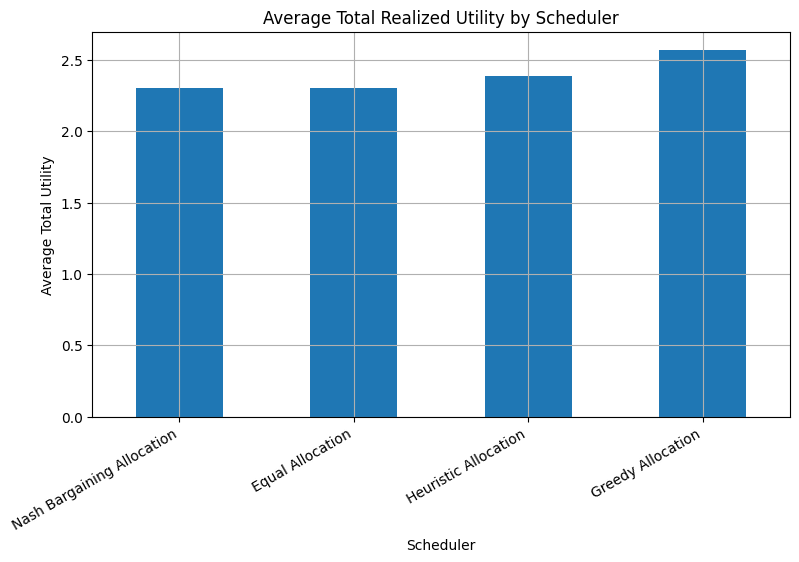

In [11]:
ax = summary_df["total_utility"].plot(kind="bar")
ax.set_title("Average Total Realized Utility by Scheduler")
ax.set_ylabel("Average Total Utility")
ax.set_xlabel("Scheduler")
plt.xticks(rotation=30, ha="right")
plt.show()


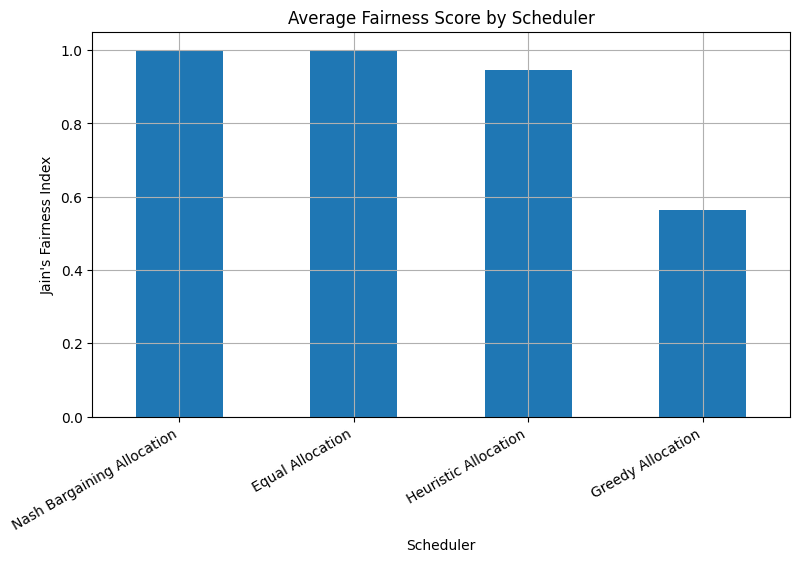

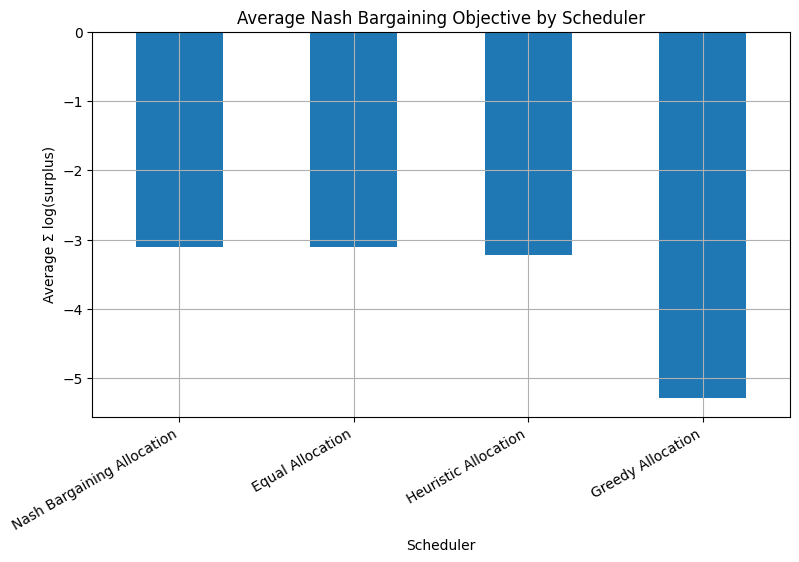

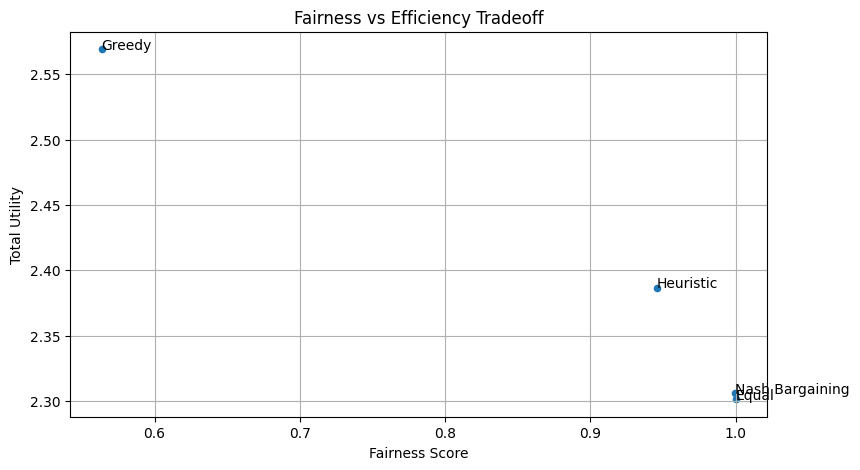

In [12]:
ax = summary_df["fairness_score"].plot(kind="bar")
ax.set_title("Average Fairness Score by Scheduler")
ax.set_ylabel("Jain's Fairness Index")
ax.set_xlabel("Scheduler")
plt.xticks(rotation=30, ha="right")
plt.show()

ax = summary_df["nash_objective"].plot(kind="bar")
ax.set_title("Average Nash Bargaining Objective by Scheduler")
ax.set_ylabel("Average Σ log(surplus)")
ax.set_xlabel("Scheduler")
plt.xticks(rotation=30, ha="right")
plt.show()

ax = summary_df.plot.scatter(x="fairness_score", y="total_utility")
for method, row in summary_df.iterrows():
    ax.annotate(method.replace(" Allocation", ""), (row["fairness_score"], row["total_utility"]))
ax.set_title("Fairness vs Efficiency Tradeoff")
ax.set_xlabel("Fairness Score")
ax.set_ylabel("Total Utility")
plt.show()


## 9. Allocation Charts for Every Task

These charts show how each scheduler behaves differently depending on task type.

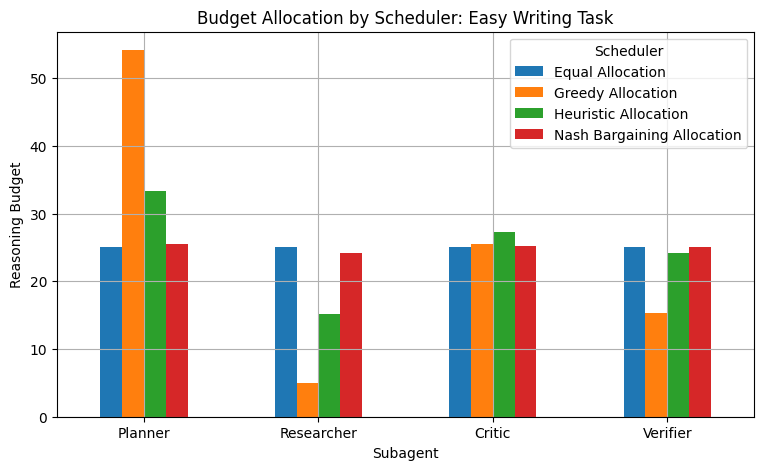

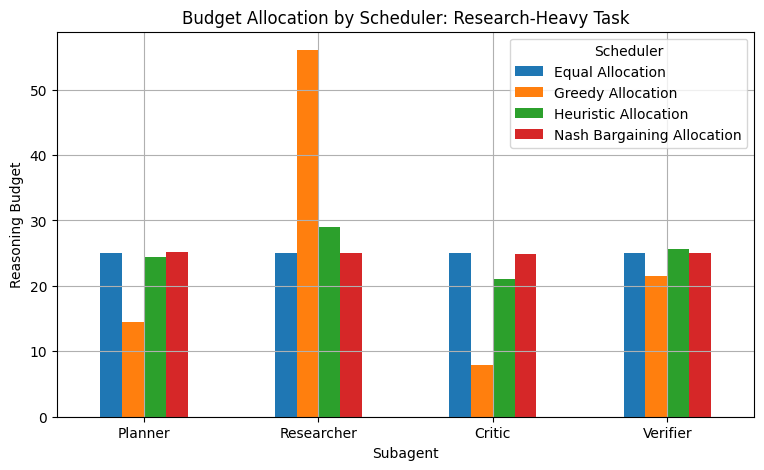

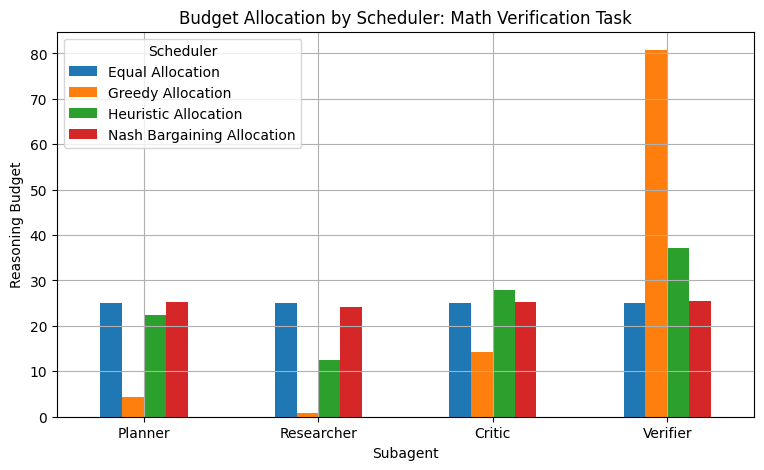

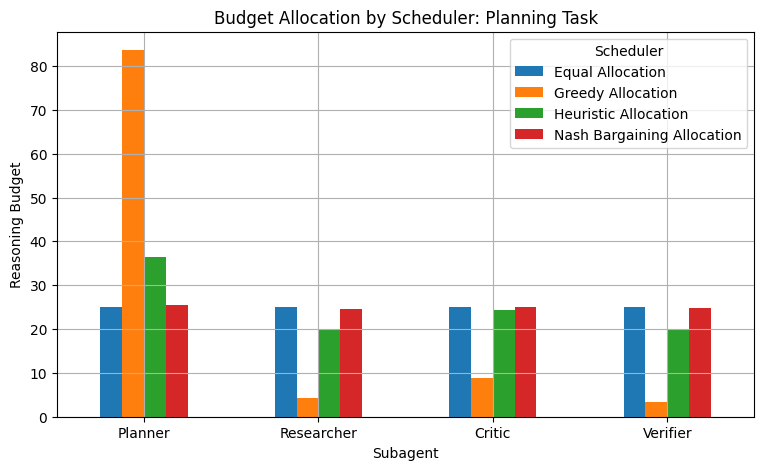

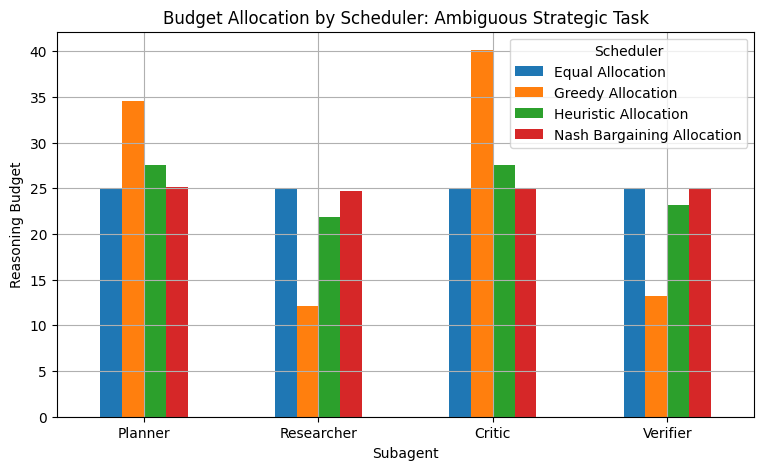

In [13]:
for task_name in tasks.keys():
    plot_task_allocations(task_name)

## 9.5 Time-Series Adaptation Demo

This section simulates ASRA over repeated task cycles. The task environment changes over time, and the scheduler recomputes allocations for each task.

This helps demonstrate adaptability: ASRA is not a one-time allocation chart; it can update the resource distribution as the reasoning environment changes.


In [14]:
task_sequence = [
    "Easy Writing Task",
    "Research-Heavy Task",
    "Math Verification Task",
    "Planning Task",
    "Ambiguous Strategic Task",
]

history_rows = []

for t, task_name in enumerate(task_sequence, start=1):
    result = run_allocations_for_task(task_name)
    for _, row in result.iterrows():
        history_rows.append({
            "iteration": t,
            "task": task_name,
            "agent": row["agent"],
            "allocation": row["Nash Bargaining Allocation"]
        })

history_df = pd.DataFrame(history_rows)
history_df.head()


,iteration,task,agent,allocation
0,1,Easy Writing Task,Planner,25.509509
1,1,Easy Writing Task,Researcher,24.220671
2,1,Easy Writing Task,Critic,25.160493
3,1,Easy Writing Task,Verifier,25.109327
4,2,Research-Heavy Task,Planner,25.106240


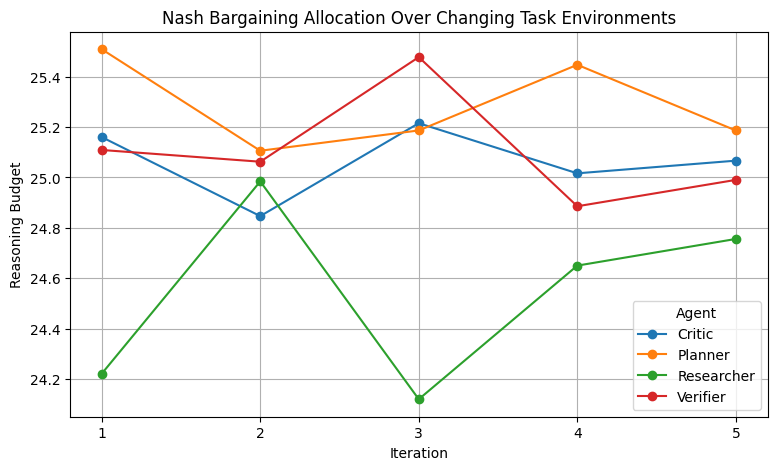

In [15]:
pivot_history = history_df.pivot_table(
    index="iteration",
    columns="agent",
    values="allocation"
)

ax = pivot_history.plot(kind="line", marker="o")
ax.set_title("Nash Bargaining Allocation Over Changing Task Environments")
ax.set_ylabel("Reasoning Budget")
ax.set_xlabel("Iteration")
plt.xticks(task_sequence and range(1, len(task_sequence) + 1))
plt.legend(title="Agent")
plt.show()


## 10. Interpretation

The equal scheduler is the most mechanically balanced, but it does not adapt to task differences. It gives the same amount of reasoning budget to every agent, even when some agents are clearly more useful for the task.

The greedy scheduler is more adaptive, but it can over-prioritize the highest-value agent. This may create imbalance because useful supporting agents receive very little budget.

The heuristic scheduler preserves the original MVP logic. It is useful as a baseline because it shows what happens when ASRA uses a simple score formula without solving a formal bargaining problem.

The Nash bargaining scheduler is the strongest game-theoretic version. It treats subagents as players, defines a disagreement point, and chooses the allocation that maximizes the Nash product through the equivalent log objective:

```txt
max_x Σ log(u_i(x_i) - d_i)
```

This connects directly to cooperative bargaining in game theory. The result is not merely a fairness heuristic; it is a formal allocation rule that balances efficiency with proportional fairness above each player's disagreement point.


## 11. Final Project Summary

This notebook builds **Iteration B** of ASRA: Adaptive Strategic Reasoning Architecture.

The system models reasoning subagents as players in a cooperative bargaining game. Each player receives utility from a finite reasoning budget, and utility depends on relevance, urgency, historical success, baseline value, and cost.

The major upgrade in this version is that ASRA now implements a real Nash bargaining scheduler:

```txt
max_x Σ log(u_i(x_i) - d_i)
```

subject to:

```txt
Σx_i = B
x_i ≥ 0
u_i(x_i) > d_i
```

This notebook compares four allocation methods:

1. Equal allocation
2. Greedy allocation
3. Heuristic allocation
4. Nash bargaining allocation

The main takeaway is that the Nash bargaining scheduler provides a professor-defensible game theory foundation for ASRA. It is no longer just a scheduler inspired by bargaining language; it now directly implements a cooperative bargaining solution concept.

## Possible Future Work

- Replace simulated utilities with real LLM output scores.
- Add memory so agent success changes over time.
- Add repeated-game dynamics across multiple tasks.
- Compare against replicator dynamics or fictitious play.
- Test the scheduler on real multi-agent reasoning tasks.
- Add more agents, such as Executor, Summarizer, and Risk Analyst.
